Test Accuracy: 97.22%
OOB Score:     97.08%


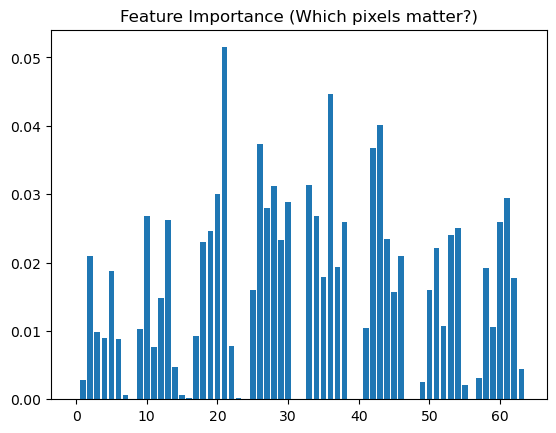

In [1]:
import pandas as pd
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# 1. Load Data (Handwritten digits 0-9)
digits = load_digits()
X = digits.data
y = digits.target

# 2. Split Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Train Random Forest
# n_estimators=100: We are building 100 trees
# oob_score=True: Calculate accuracy on the leftover data automatically
rf = RandomForestClassifier(n_estimators=100, oob_score=True, random_state=42)
rf.fit(X_train, y_train)

# 4. Predict
y_pred = rf.predict(X_test)

print(f"Test Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print(f"OOB Score:     {rf.oob_score_ * 100:.2f}%")

# 5. Feature Importance
# Random Forest can tell us which pixels (features) were most useful for distinguishing numbers
import matplotlib.pyplot as plt
plt.bar(range(X.shape[1]), rf.feature_importances_)
plt.title("Feature Importance (Which pixels matter?)")
plt.show()